In [1]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
emo = pd.read_csv('Emotion_classify_Data.csv')
mh = pd.read_csv('Combined_Data.csv')

print(emo.shape, mh.shape)
emo.head()

(5937, 2) (53043, 3)


,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [3]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)           # remove urls
    text = re.sub(r'[^a-z0-9\s!?.,\']', ' ', text)          # keep basic punctuation (signal for emotion/crisis)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [4]:
emo = emo.rename(columns={'Comment': 'text', 'Emotion': 'label'})
emo = emo.dropna(subset=['text', 'label'])
emo['text'] = emo['text'].apply(clean_text)
emo = emo.drop_duplicates(subset=['text'])
emo = emo[emo['text'].str.len() > 0]

print("Emotion dataset:", emo.shape)
print(emo['label'].value_counts())

Emotion dataset: (5934, 2)
label
anger    2000
joy      2000
fear     1934
Name: count, dtype: int64


In [5]:
mh = mh.rename(columns={'statement': 'text', 'status': 'label'})
mh = mh[['text', 'label']]
mh = mh.dropna(subset=['text', 'label'])
mh['text'] = mh['text'].apply(clean_text)
mh = mh.drop_duplicates(subset=['text'])
mh = mh[mh['text'].str.len() > 0]

print("Mental health dataset:", mh.shape)
print(mh['label'].value_counts())

Mental health dataset: (51017, 2)
label
Normal                  16003
Depression              15085
Suicidal                10638
Anxiety                  3608
Bipolar                  2501
Stress                   2288
Personality disorder      894
Name: count, dtype: int64


In [6]:
emo_train, emo_test = train_test_split(
    emo, test_size=0.2, random_state=42, stratify=emo['label']
)
mh_train, mh_test = train_test_split(
    mh, test_size=0.2, random_state=42, stratify=mh['label']
)

emo_train.to_csv('emotion_train.csv', index=False)
emo_test.to_csv('emotion_test.csv', index=False)
mh_train.to_csv('mh_train.csv', index=False)
mh_test.to_csv('mh_test.csv', index=False)

print("Emotion -> train:", emo_train.shape, "test:", emo_test.shape)
print("Mental health -> train:", mh_train.shape, "test:", mh_test.shape)

Emotion -> train: (4747, 2) test: (1187, 2)
Mental health -> train: (40813, 2) test: (10204, 2)


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [8]:
emo_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_emo_train = emo_vectorizer.fit_transform(emo_train['text'])
X_emo_test = emo_vectorizer.transform(emo_test['text'])
y_emo_train = emo_train['label']
y_emo_test = emo_test['label']

print(X_emo_train.shape, X_emo_test.shape)

(4747, 11593) (1187, 11593)


In [9]:
mh_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_mh_train = mh_vectorizer.fit_transform(mh_train['text'])
X_mh_test = mh_vectorizer.transform(mh_test['text'])
y_mh_train = mh_train['label']
y_mh_test = mh_test['label']

print(X_mh_train.shape, X_mh_test.shape)

(40813, 20000) (10204, 20000)


In [10]:
emo_logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
emo_logreg.fit(X_emo_train, y_emo_train)

emo_svm = LinearSVC(class_weight='balanced')
emo_svm.fit(X_emo_train, y_emo_train)

print("Emotion models trained.")

Emotion models trained.


In [11]:
mh_logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
mh_logreg.fit(X_mh_train, y_mh_train)

mh_svm = LinearSVC(class_weight='balanced')
mh_svm.fit(X_mh_train, y_mh_train)

print("Mental health models trained.")

Mental health models trained.


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
print("=== Emotion: Logistic Regression ===")
emo_logreg_preds = emo_logreg.predict(X_emo_test)
print(classification_report(y_emo_test, emo_logreg_preds))

print("=== Emotion: Linear SVM ===")
emo_svm_preds = emo_svm.predict(X_emo_test)
print(classification_report(y_emo_test, emo_svm_preds))

=== Emotion: Logistic Regression ===
              precision    recall  f1-score   support

       anger       0.87      0.86      0.87       400
        fear       0.87      0.87      0.87       387
         joy       0.86      0.88      0.87       400

    accuracy                           0.87      1187
   macro avg       0.87      0.87      0.87      1187
weighted avg       0.87      0.87      0.87      1187

=== Emotion: Linear SVM ===
              precision    recall  f1-score   support

       anger       0.90      0.90      0.90       400
        fear       0.90      0.92      0.91       387
         joy       0.92      0.91      0.91       400

    accuracy                           0.91      1187
   macro avg       0.91      0.91      0.91      1187
weighted avg       0.91      0.91      0.91      1187



In [14]:
print("=== Mental Health: Logistic Regression ===")
mh_logreg_preds = mh_logreg.predict(X_mh_test)
print(classification_report(y_mh_test, mh_logreg_preds))

print("=== Mental Health: Linear SVM ===")
mh_svm_preds = mh_svm.predict(X_mh_test)
print(classification_report(y_mh_test, mh_svm_preds))

=== Mental Health: Logistic Regression ===
                      precision    recall  f1-score   support

             Anxiety       0.76      0.83      0.79       722
             Bipolar       0.73      0.77      0.75       500
          Depression       0.80      0.60      0.69      3017
              Normal       0.90      0.92      0.91      3201
Personality disorder       0.48      0.65      0.55       179
              Stress       0.48      0.70      0.57       457
            Suicidal       0.66      0.75      0.71      2128

            accuracy                           0.76     10204
           macro avg       0.69      0.75      0.71     10204
        weighted avg       0.77      0.76      0.76     10204

=== Mental Health: Linear SVM ===
                      precision    recall  f1-score   support

             Anxiety       0.77      0.82      0.79       722
             Bipolar       0.78      0.72      0.75       500
          Depression       0.74      0.66      0.69

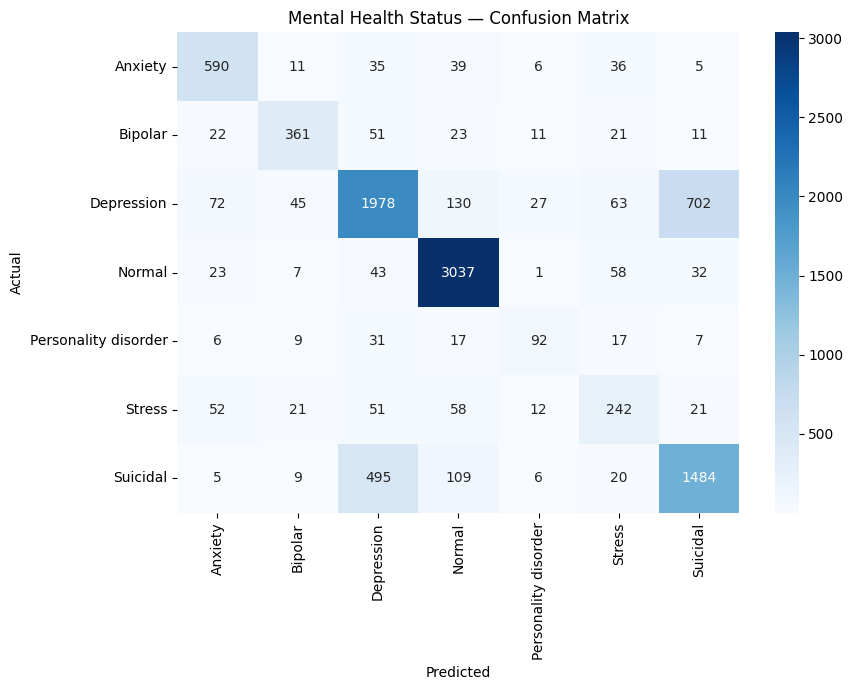

In [15]:
# Change mh_svm_preds -> mh_logreg_preds below once you know which model won in Cell 14
labels = sorted(y_mh_test.unique())
cm = confusion_matrix(y_mh_test, mh_svm_preds, labels=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Mental Health Status — Confusion Matrix')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

In [17]:
# Custom scorer: recall specifically on the "Suicidal" class
def suicidal_recall(y_true, y_pred):
    return recall_score(y_true, y_pred, labels=['Suicidal'], average='macro')

suicidal_scorer = make_scorer(suicidal_recall)

param_grid = {'C': [0.1, 0.5, 1.0, 2.0, 5.0]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    scoring=suicidal_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_mh_train, y_mh_train)

print("Best C:", grid.best_params_)
print("Best CV Suicidal recall:", grid.best_score_)

mh_logreg_tuned = grid.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best C: {'C': 1.0}
Best CV Suicidal recall: 0.7366623281345522


In [18]:
mh_tuned_preds = mh_logreg_tuned.predict(X_mh_test)
print(classification_report(y_mh_test, mh_tuned_preds))

                      precision    recall  f1-score   support

             Anxiety       0.76      0.83      0.79       722
             Bipolar       0.73      0.77      0.75       500
          Depression       0.80      0.60      0.69      3017
              Normal       0.90      0.92      0.91      3201
Personality disorder       0.48      0.65      0.55       179
              Stress       0.48      0.70      0.57       457
            Suicidal       0.66      0.75      0.71      2128

            accuracy                           0.76     10204
           macro avg       0.69      0.75      0.71     10204
        weighted avg       0.77      0.76      0.76     10204



In [19]:
import pandas as pd

# Full emotion data
emo_full = pd.concat([emo_train, emo_test])
X_emo_full = emo_vectorizer.fit_transform(emo_full['text'])
y_emo_full = emo_full['label']

emo_final_model = LinearSVC(class_weight='balanced')
emo_final_model.fit(X_emo_full, y_emo_full)

# Full mental health data
mh_full = pd.concat([mh_train, mh_test])
X_mh_full = mh_vectorizer.fit_transform(mh_full['text'])
y_mh_full = mh_full['label']

mh_final_model = LogisticRegression(max_iter=1000, class_weight='balanced')
mh_final_model.fit(X_mh_full, y_mh_full)

print("Final models retrained on full data.")
print("Emotion vocab size:", len(emo_vectorizer.vocabulary_))
print("Mental health vocab size:", len(mh_vectorizer.vocabulary_))

Final models retrained on full data.
Emotion vocab size: 14193
Mental health vocab size: 20000


In [20]:
import pickle

with open('emotion_vectorizer.pkl', 'wb') as f:
    pickle.dump(emo_vectorizer, f)

with open('emotion_model.pkl', 'wb') as f:
    pickle.dump(emo_final_model, f)

with open('mh_vectorizer.pkl', 'wb') as f:
    pickle.dump(mh_vectorizer, f)

with open('mh_model.pkl', 'wb') as f:
    pickle.dump(mh_final_model, f)

print("Saved: emotion_vectorizer.pkl, emotion_model.pkl, mh_vectorizer.pkl, mh_model.pkl")

Saved: emotion_vectorizer.pkl, emotion_model.pkl, mh_vectorizer.pkl, mh_model.pkl


In [21]:
with open('emotion_vectorizer.pkl', 'rb') as f:
    v1 = pickle.load(f)
with open('emotion_model.pkl', 'rb') as f:
    m1 = pickle.load(f)
with open('mh_vectorizer.pkl', 'rb') as f:
    v2 = pickle.load(f)
with open('mh_model.pkl', 'rb') as f:
    m2 = pickle.load(f)

sample = ["i feel like i cant go on anymore and nothing matters"]
print("Emotion prediction:", m1.predict(v1.transform(sample)))
print("Mental health prediction:", m2.predict(v2.transform(sample)))

Emotion prediction: ['anger']
Mental health prediction: ['Normal']


In [22]:
test_phrases = [
    "i feel like i cant go on anymore and nothing matters",
    "i want to end my life",
    "there's no point in living anymore",
    "i just want to disappear forever",
    "i've been thinking about hurting myself",
    "everything feels hopeless and i dont want to be here",
    "i had a great day today feeling really happy",
    "work has been stressful lately but manageable"
]

for phrase in test_phrases:
    pred = m2.predict(v2.transform([phrase]))[0]
    print(f"{pred:25s} <- {phrase}")

Normal                    <- i feel like i cant go on anymore and nothing matters
Suicidal                  <- i want to end my life
Normal                    <- there's no point in living anymore
Suicidal                  <- i just want to disappear forever
Normal                    <- i've been thinking about hurting myself
Suicidal                  <- everything feels hopeless and i dont want to be here
Normal                    <- i had a great day today feeling really happy
Normal                    <- work has been stressful lately but manageable


In [23]:
CRISIS_KEYWORDS = [
    "want to die", "end my life", "kill myself", "suicide", "suicidal",
    "no reason to live", "cant go on", "can't go on", "want to disappear",
    "hurting myself", "hurt myself", "not worth living", "better off dead",
    "give up on life"
]

def keyword_crisis_flag(text: str) -> bool:
    text = text.lower()
    return any(kw in text for kw in CRISIS_KEYWORDS)

def combined_crisis_check(text: str, vectorizer, model) -> dict:
    ml_pred = model.predict(vectorizer.transform([text]))[0]
    kw_flag = keyword_crisis_flag(text)
    final_risk = (ml_pred == "Suicidal") or kw_flag
    return {
        "text": text,
        "ml_prediction": ml_pred,
        "keyword_flag": kw_flag,
        "final_crisis_flag": final_risk
    }

for phrase in test_phrases:
    print(combined_crisis_check(phrase, v2, m2))

{'text': 'i feel like i cant go on anymore and nothing matters', 'ml_prediction': 'Normal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': 'i want to end my life', 'ml_prediction': 'Suicidal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': "there's no point in living anymore", 'ml_prediction': 'Normal', 'keyword_flag': False, 'final_crisis_flag': False}
{'text': 'i just want to disappear forever', 'ml_prediction': 'Suicidal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': "i've been thinking about hurting myself", 'ml_prediction': 'Normal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': 'everything feels hopeless and i dont want to be here', 'ml_prediction': 'Suicidal', 'keyword_flag': False, 'final_crisis_flag': True}
{'text': 'i had a great day today feeling really happy', 'ml_prediction': 'Normal', 'keyword_flag': False, 'final_crisis_flag': False}
{'text': 'work has been stressful lately but manageable', 'ml_prediction': 'Normal', 'keywor

In [24]:
CRISIS_KEYWORDS = [
    "want to die", "end my life", "kill myself", "suicide", "suicidal",
    "no reason to live", "no point in living", "no point living",
    "cant go on", "can't go on", "want to disappear", "disappear forever",
    "hurting myself", "hurt myself", "not worth living", "better off dead",
    "give up on life", "dont want to be here", "don't want to be here",
    "cant do this anymore", "can't do this anymore", "end it all",
    "not worth it anymore", "wish i wasnt alive", "wish i wasn't alive"
]

def keyword_crisis_flag(text: str) -> bool:
    text = text.lower()
    return any(kw in text for kw in CRISIS_KEYWORDS)

for phrase in test_phrases:
    print(combined_crisis_check(phrase, v2, m2))

{'text': 'i feel like i cant go on anymore and nothing matters', 'ml_prediction': 'Normal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': 'i want to end my life', 'ml_prediction': 'Suicidal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': "there's no point in living anymore", 'ml_prediction': 'Normal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': 'i just want to disappear forever', 'ml_prediction': 'Suicidal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': "i've been thinking about hurting myself", 'ml_prediction': 'Normal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': 'everything feels hopeless and i dont want to be here', 'ml_prediction': 'Suicidal', 'keyword_flag': True, 'final_crisis_flag': True}
{'text': 'i had a great day today feeling really happy', 'ml_prediction': 'Normal', 'keyword_flag': False, 'final_crisis_flag': False}
{'text': 'work has been stressful lately but manageable', 'ml_prediction': 'Normal', 'keyword_f

In [25]:
import json

with open('crisis_keywords.json', 'w') as f:
    json.dump(CRISIS_KEYWORDS, f)

def analyze_message(text: str) -> dict:
    """
    Single entry point for the backend: emotion + mental health status + crisis flag.
    """
    emotion = m1.predict(v1.transform([text]))[0]
    mh_status = m2.predict(v2.transform([text]))[0]
    kw_flag = keyword_crisis_flag(text)
    crisis_flag = (mh_status == "Suicidal") or kw_flag

    return {
        "emotion": emotion,
        "mental_health_status": mh_status,
        "crisis_flag": crisis_flag
    }

# quick test
print(analyze_message("there's no point in living anymore"))
print(analyze_message("i had a lovely relaxing weekend"))

{'emotion': 'joy', 'mental_health_status': 'Normal', 'crisis_flag': True}
{'emotion': 'anger', 'mental_health_status': 'Normal', 'crisis_flag': False}


In [26]:
sample_texts = [
    "i feel like i cant go on anymore and nothing matters",
    "i want to end my life",
    "there's no point in living anymore",
    "i just want to disappear forever",
    "i've been thinking about hurting myself",
    "everything feels hopeless and i dont want to be here",
    "i had a great day today feeling really happy",
    "work has been stressful lately but manageable",
    "i had a lovely relaxing weekend",
    "i am so proud of what i accomplished today",
    "im really angry that nobody listens to me",
    "i feel anxious about my exam tomorrow"
]

results = []
for text in sample_texts:
    emotion_pred = m1.predict(v1.transform([text]))[0]
    mh_pred = m2.predict(v2.transform([text]))[0]
    kw_flag = keyword_crisis_flag(text)
    crisis_flag = (mh_pred == "Suicidal") or kw_flag

    results.append({
        "text": text,
        "predicted_emotion": emotion_pred,
        "predicted_mh_status": mh_pred,
        "keyword_flag": kw_flag,
        "crisis_flag": crisis_flag
    })

results_df = pd.DataFrame(results)
results_df

,text,predicted_emotion,predicted_mh_status,keyword_flag,crisis_flag
0,i feel like i cant go on anymore and nothing m...,anger,Normal,True,True
1,i want to end my life,anger,Suicidal,True,True
2,there's no point in living anymore,joy,Normal,True,True
3,i just want to disappear forever,joy,Suicidal,True,True
4,i've been thinking about hurting myself,joy,Normal,True,True
5,everything feels hopeless and i dont want to b...,fear,Suicidal,True,True
6,i had a great day today feeling really happy,joy,Normal,False,False
7,work has been stressful lately but manageable,anger,Normal,False,False
8,i had a lovely relaxing weekend,anger,Normal,False,False
9,i am so proud of what i accomplished today,joy,Normal,False,False
